In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import sklearn as sk
import seaborn as sns
import datetime as dt
import re
from datetime import datetime


In [3]:
df = pd.read_csv('total_call_data.csv') 

C:\Users\Owner\AppData\Local\Temp\ipykernel_7844\3987048458.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('total_call_data.csv')


In [26]:
# Find indices where condition is True
idx = df.index[df['Activity Name'] == 'ClosedMenu']

# Add preceding and following indices
expanded_idx = idx.union(idx - 1).union(idx + 1)

# Keep only valid indices within dataframe bounds
expanded_idx = expanded_idx.intersection(df.index)

# Select rows
df_main = df.loc[expanded_idx].reset_index(drop=True)

In [27]:
df_main.head()

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,hour
0,02de749f-a394-47f9-aadb-daa6ed231535,NaN,ClosedHoursHolidaysMenu,NaN,2025-01-13 16:35:31,NaN,NaN,NaN,16
1,02de749f-a394-47f9-aadb-daa6ed231535,Closed Hours-Holidays Menu Telephony EP,NaN,ClosedMenu,2025-01-13 16:35:31,NaN,NaN,NaN,16
2,02de749f-a394-47f9-aadb-daa6ed231535,Closed Hours-Holidays Menu Telephony EP,NaN,DisconnectContact1,2025-01-13 16:35:44,NaN,NaN,NaN,16
3,033c1673-f130-4652-9ffe-0a4732241191,NaN,ClosedHoursHolidaysMenu,NaN,2025-01-13 16:37:47,NaN,NaN,NaN,16
4,033c1673-f130-4652-9ffe-0a4732241191,Closed Hours-Holidays Menu Telephony EP,NaN,ClosedMenu,2025-01-13 16:37:47,NaN,NaN,NaN,16


In [23]:
# Find indices where condition is True
idx = df.index[df['Activity Name'] == 'ClosedQueueMenu']

# Add preceding and following indices
expanded_idx = idx.union(idx - 1).union(idx + 1)

# Keep only valid indices within dataframe bounds
expanded_idx = expanded_idx.intersection(df.index)

# Select rows
df_main_queue = df.loc[expanded_idx].reset_index(drop=True)

In [28]:
df_new = pd.DataFrame() # initialize empty dataframe

for i, row in df_main.iterrows(): # iterate over rows of df

    # checks if Activity Name is 'ClosedMenu' and if the next row has the same Contact Session ID
    # This tells us the call continued after the menu was closed, allowing us to track time spent on the closed menu
    if row['Activity Name'] == 'ClosedMenu' and row['Contact Session ID'] == df_main.at[i+1, 'Contact Session ID']:
        df_new = pd.concat([df_new, pd.DataFrame(df_main.loc[i:i+1]).reset_index(drop=True)], ignore_index=True, axis=0)
    


In [30]:
df_new_queue = pd.DataFrame() # initialize empty dataframe for queue menus
for i, row in df_main_queue.iterrows(): # iterate over rows of df
    # Does same thing for 'ClosedQueueMenu', which will probably be more helpful
    if row['Activity Name'] == 'ClosedQueueMenu' and row['Contact Session ID'] == df_main_queue.at[i+1, 'Contact Session ID']:
        df_new_queue = pd.concat([df_new_queue, pd.DataFrame(df_main_queue.loc[i:i+1]).reset_index(drop=True)], ignore_index=True, axis=0)

In [ ]:
# converting to datetime objects for time calculations
df_new["Activity Start Timestamp"] = df_new["Activity Start Timestamp"].apply(
    lambda x: datetime.strptime(x, "%Y-%m-%d %H:%M:%S"))

df_new_queue["Activity Start Timestamp"] = df_new_queue["Activity Start Timestamp"].apply(
    lambda x: datetime.strptime(x, "%Y-%m-%d %H:%M:%S"))

In [33]:
# Creating a time delta column
df_new['Time_Since_Close'] = 0
for i, row in df_new.iterrows():
    if row['Activity Name'] == 'ClosedMenu':
        time1 = row['Activity Start Timestamp']
        time2 = df_new.at[i+1, 'Activity Start Timestamp']
        delta = time2 - time1   
        df_new.at[i, 'Time_Since_Close'] = delta.total_seconds()

df_new_queue['Time_Since_Close'] = 0
for i, row in df_new_queue.iterrows():
    if row['Activity Name'] == 'ClosedQueueMenu':
        time1 = row['Activity Start Timestamp']
        time2 = df_new_queue.at[i+1, 'Activity Start Timestamp']
        delta = time2 - time1
        df_new_queue.at[i, 'Time_Since_Close'] = delta.total_seconds()
        df_new.at[i, 'Time_Since_Close'] = delta.total_seconds()

        

In [ ]:
# Just keeping the rows with 'ClosedMenu' and "ClosedQueueMenu" for final analysis
df_final = df_new[df_new['Activity Name'] == 'ClosedMenu'].reset_index(drop=True)
df_final_queue = df_new_queue[df_new_queue['Activity Name'] == 'ClosedQueueMenu'].reset_index(drop=True)

In [37]:
df_final.to_excel('Time_On_Closed_menu.xlsx', index=False)
df_final_queue.to_excel('Time_On_Closed_Queue_menu.xlsx', index=False)

### Below are some graphs to visualize the time

<Axes: xlabel='Time_Since_Close', ylabel='Density'>

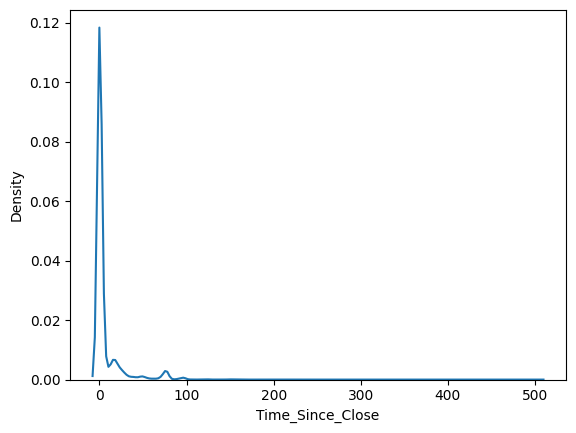

In [38]:
sns.kdeplot(df_final['Time_Since_Close'])

<Axes: xlabel='Time_Since_Close', ylabel='Proportion'>

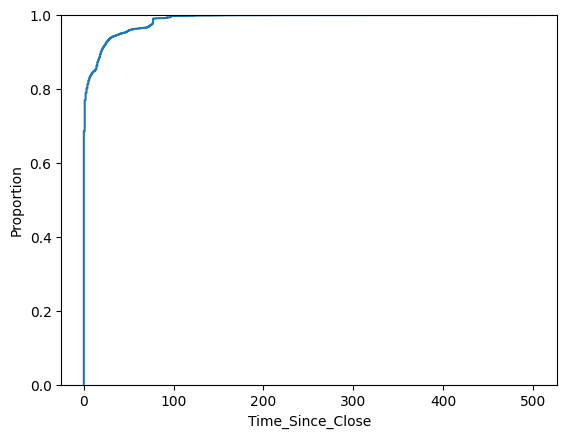

In [39]:
sns.ecdfplot(df_final['Time_Since_Close'])